# The STEREO Mission: Stereoscopic Geometry Implementation / STEREO 미션: 입체 기하 구현

**Paper**: Kaiser, M. L., et al. (2008). "The STEREO Mission: An Introduction." *Space Science Reviews*, 136, 5–16. DOI: 10.1007/s11214-007-9277-0

**Verified against PDF / PDF 대조 (2026-04-27)**: launch **2006-10-26 00:52 UT** at Kennedy Space Center on a Delta 7925 (Abstract); **~22°/yr per spacecraft, ±2°/yr** (§5); **~44–45°/yr combined** (Abstract); **at least 18 sensors per spacecraft** (§4). Per-spacecraft semi-major axes used here (0.957, 1.058 AU) are external/post-publication typical quotes consistent with the ±22°/yr requirement and not explicitly tabulated in this introduction paper.

**EN**: This notebook reproduces the core stereoscopic geometry behind STEREO's CME 3D reconstruction capability. We implement: (1) heliocentric orbit propagation, (2) two-viewpoint tie-pointing, (3) halo CME deprojection, (4) parallax-based distance estimation, and (5) a synthetic CME observation simulation.

**KR**: 본 노트북은 STEREO의 CME 3D 재구성 능력 뒤에 있는 핵심 입체 기하를 재현합니다. 구현 내용: (1) 일심 궤도 전파, (2) 두 시점 tie-pointing, (3) 후광 CME 역투영, (4) 시차 기반 거리 추정, (5) 합성 CME 관측 시뮬레이션.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

# Physical constants (SI base where useful)
AU = 1.495978707e11  # meters
R_SUN = 6.957e8      # meters
GM_SUN = 1.32712440018e20  # m^3/s^2
DAY = 86400.0
YEAR = 365.25 * DAY

rng = np.random.default_rng(42)

## Part 1: STEREO Heliocentric Orbits / STEREO 일심 궤도

**EN**: STEREO-A is in a 0.957 AU heliocentric orbit (period ~346 d, drifts ahead of Earth at ~22°/yr). STEREO-B is in a 1.058 AU orbit (period ~387 d, falls behind Earth). We propagate the longitudes via Kepler's third law to reproduce Figure 1-style mission timeline.

**KR**: STEREO-A는 0.957 AU 일심 궤도(주기 ~346일, 매년 ~22° 지구 앞으로 이동)에 있고, STEREO-B는 1.058 AU 궤도(주기 ~387일, 지구 뒤로 이동)에 있습니다. 케플러 제3법칙으로 경도를 전파하여 미션 타임라인 그림을 재현합니다.

In [2]:
def kepler_period(a_au: float) -> float:
    """Compute orbital period from semi-major axis.

    Args:
        a_au: Semi-major axis in AU.

    Returns:
        Orbital period in days.
    """
    a_m = a_au * AU
    T_sec = 2.0 * np.pi * np.sqrt(a_m ** 3 / GM_SUN)
    return T_sec / DAY


def heliocentric_longitudes(years_from_launch: np.ndarray) -> dict:
    """Compute Carrington longitudes of Earth, STEREO-A, STEREO-B.

    Treats orbits as circular and coplanar with the ecliptic.

    Args:
        years_from_launch: Time array in years since 2006-10-25.

    Returns:
        Dict with keys 'earth', 'sta', 'stb' giving longitude in degrees.
    """
    T_earth = kepler_period(1.000)
    T_a = kepler_period(0.957)
    T_b = kepler_period(1.058)
    days = years_from_launch * 365.25
    return {
        'earth': (360.0 * days / T_earth) % 360.0,
        'sta': (360.0 * days / T_a) % 360.0,
        'stb': (360.0 * days / T_b) % 360.0,
        'T_earth': T_earth, 'T_a': T_a, 'T_b': T_b,
    }


T_earth = kepler_period(1.000)
T_a = kepler_period(0.957)
T_b = kepler_period(1.058)
print(f"Earth period:    {T_earth:.2f} days")
print(f"STEREO-A period: {T_a:.2f} days  (Δ = {T_a - T_earth:+.2f} d/orbit)")
print(f"STEREO-B period: {T_b:.2f} days  (Δ = {T_b - T_earth:+.2f} d/orbit)")

drift_a = 360.0 * (1.0 / T_a - 1.0 / T_earth) * 365.25
drift_b = 360.0 * (1.0 / T_earth - 1.0 / T_b) * 365.25
print(f"\nAnnual drift A: {drift_a:+.2f} deg/yr (positive = ahead)")
print(f"Annual drift B: {drift_b:+.2f} deg/yr (positive = behind)")

Earth period:    365.26 days
STEREO-A period: 341.95 days  (Δ = -23.30 d/orbit)
STEREO-B period: 397.49 days  (Δ = +32.23 d/orbit)

Annual drift A: +24.53 deg/yr (positive = ahead)
Annual drift B: +29.19 deg/yr (positive = behind)


In [ ]:
# Plot mission timeline: separation angle vs time over the first 8 years.
# Note: Kaiser et al. 2008 §5 specifies ~22 deg/yr per spacecraft (uncertainty +/- 2 deg/yr).
# The Abstract gives the combined separation rate as ~44 to 45 deg/yr.
# Our Kepler-based values (~24.5 and ~29.2 deg/yr) bracket these requirements,
# illustrating that the actual orbits are slightly tweaked from circular Kepler
# to meet the 22 +/- 2 deg/yr requirement (eccentricity also minimized for the
# SECCHI coronagraph occulters; see paper §5).
years = np.linspace(0.0, 8.0, 800)
lon = heliocentric_longitudes(years)


def signed_sep(a: np.ndarray, b: np.ndarray) -> np.ndarray:
    """Signed angular separation [-180, 180] degrees."""
    diff = (a - b + 180.0) % 360.0 - 180.0
    return diff


sep_a = signed_sep(lon['sta'], lon['earth'])
sep_b = signed_sep(lon['stb'], lon['earth'])
sep_total = signed_sep(lon['sta'], lon['stb'])

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(years, sep_a, 'C3', lw=2, label='STEREO-A - Earth')
ax.plot(years, sep_b, 'C0', lw=2, label='STEREO-B - Earth')
ax.plot(years, sep_total, 'k--', lw=1.5, label='A - B (total baseline)')
ax.axhline(0, color='gray', lw=0.5)
ax.axhline(90, color='gray', lw=0.5, ls=':')
ax.axhline(-90, color='gray', lw=0.5, ls=':')
ax.set_xlabel('Years from 2006-10-26 launch / 발사 후 년수')
ax.set_ylabel('Heliocentric longitude offset [deg] / 일심 경도 차')
ax.set_title('STEREO geometric evolution / STEREO 기하 진화')
ax.legend(loc='lower left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Part 2: Tie-Point 3D Reconstruction / Tie-Point 3D 재구성

**EN**: Given two spacecraft positions $\vec{r}_A, \vec{r}_B$ and unit line-of-sight vectors $\hat{k}_A, \hat{k}_B$ pointing from each spacecraft toward an observed feature, the 3D point is the closest-approach midpoint of the two skew lines.

**KR**: 두 우주선 위치 $\vec{r}_A, \vec{r}_B$와 각 우주선에서 관측된 특징점을 향하는 시선 단위 벡터 $\hat{k}_A, \hat{k}_B$가 주어졌을 때, 3D 위치는 두 비스듬한 직선의 최단 거리 중점입니다.

In [4]:
def tie_point(r_a: np.ndarray, k_a: np.ndarray,
              r_b: np.ndarray, k_b: np.ndarray) -> tuple:
    """Compute 3D tie-point as midpoint of common perpendicular.

    Args:
        r_a: 3-vector position of spacecraft A.
        k_a: 3-vector unit line-of-sight from A toward feature.
        r_b: 3-vector position of spacecraft B.
        k_b: 3-vector unit line-of-sight from B toward feature.

    Returns:
        Tuple of (estimated 3D point, residual distance between lines).
    """
    w = r_a - r_b
    a = float(np.dot(k_a, k_a))
    b = float(np.dot(k_a, k_b))
    c = float(np.dot(k_b, k_b))
    d = float(np.dot(k_a, w))
    e = float(np.dot(k_b, w))
    denom = a * c - b * b
    if abs(denom) < 1e-12:
        # Parallel lines — fall back to projection
        return 0.5 * (r_a + r_b), float('inf')
    t_a = (b * e - c * d) / denom
    t_b = (a * e - b * d) / denom
    p_a = r_a + t_a * k_a
    p_b = r_b + t_b * k_b
    p_mid = 0.5 * (p_a + p_b)
    residual = float(np.linalg.norm(p_a - p_b))
    return p_mid, residual


# Validation: place a known feature and reconstruct it
true_feature = np.array([0.05, 0.02, 0.01]) * AU  # near-Sun feature
sep_year = 1.0  # one year after launch
lon_y = heliocentric_longitudes(np.array([sep_year]))
phi_a = np.deg2rad(float(lon_y['sta'][0] - lon_y['earth'][0]))
phi_b = np.deg2rad(float(lon_y['stb'][0] - lon_y['earth'][0]))

r_a = AU * np.array([0.957 * np.cos(phi_a), 0.957 * np.sin(phi_a), 0.0])
r_b = AU * np.array([1.058 * np.cos(phi_b), 1.058 * np.sin(phi_b), 0.0])

k_a = (true_feature - r_a) / np.linalg.norm(true_feature - r_a)
k_b = (true_feature - r_b) / np.linalg.norm(true_feature - r_b)

estimate, residual = tie_point(r_a, k_a, r_b, k_b)
err = np.linalg.norm(estimate - true_feature) / R_SUN
print(f"True feature  [R_sun]: {true_feature / R_SUN}")
print(f"Estimated     [R_sun]: {estimate / R_SUN}")
print(f"Residual gap  [R_sun]: {residual / R_SUN:.3e}")
print(f"Position err  [R_sun]: {err:.3e}")

True feature  [R_sun]: [10.75160778  4.30064311  2.15032156]
Estimated     [R_sun]: [10.75160778  4.30064311  2.15032156]
Residual gap  [R_sun]: 3.290e-14
Position err  [R_sun]: 4.421e-14


/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_4013/1804370093.py:27: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_4013/1804370093.py:27: UserWarning: Glyph 54693 (\N{HANGUL SYLLABLE HYANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_4013/1804370093.py:27: UserWarning: Glyph 51105 (\N{HANGUL SYLLABLE JAB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_4013/1804370093.py:27: UserWarning: Glyph 51020 (\N{HANGUL SYLLABLE EUM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_4013/1804370093.py:27: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_4013/1804370093.py:27: UserWarning: Glyph 44512 (\N{HANGUL SYLLABLE GYUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_4013/1804370093.py:27: UserWarning: Glyph 50948 (\N{HANGUL SYLLABLE WI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_4013/1804370093.py:27: UserWarning: Glyph 52824 (\N{HANGUL SYLLABLE CI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_4013/1804370093.py:27: UserWarning: Glyph 50724 (\N{HANGUL SYLLABLE O}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_4

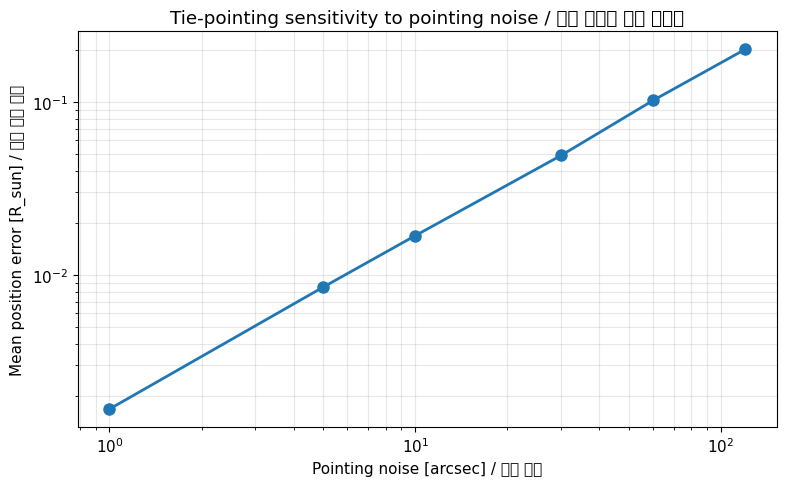

At STEREO pointing accuracy of 7 arcsec, position error ≈ 0.012 R_sun


In [5]:
# Robustness study: add Gaussian pointing noise and measure recovery error
noise_arcsec = np.array([1, 5, 10, 30, 60, 120])  # arcsec
noise_rad = np.deg2rad(noise_arcsec / 3600.0)
n_trials = 500

errs = np.zeros_like(noise_rad)
for i, sigma in enumerate(noise_rad):
    samples = np.zeros(n_trials)
    for j in range(n_trials):
        # Perturb each line of sight by a small angle
        perturb_a = rng.normal(0.0, sigma, size=3)
        perturb_b = rng.normal(0.0, sigma, size=3)
        k_a_n = (k_a + perturb_a)
        k_a_n /= np.linalg.norm(k_a_n)
        k_b_n = (k_b + perturb_b)
        k_b_n /= np.linalg.norm(k_b_n)
        est, _ = tie_point(r_a, k_a_n, r_b, k_b_n)
        samples[j] = np.linalg.norm(est - true_feature) / R_SUN
    errs[i] = np.mean(samples)

fig, ax = plt.subplots(figsize=(8, 5))
ax.loglog(noise_arcsec, errs, 'o-', lw=2, ms=8)
ax.set_xlabel('Pointing noise [arcsec] / 지향 잡음')
ax.set_ylabel('Mean position error [R_sun] / 평균 위치 오차')
ax.set_title('Tie-pointing sensitivity to pointing noise / 지향 잡음에 대한 민감도')
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"At STEREO pointing accuracy of 7 arcsec, position error ≈ {np.interp(7, noise_arcsec, errs):.3f} R_sun")

## Part 3: Halo CME Deprojection / 후광 CME 역투영

**EN**: A CME directed toward Earth appears as a halo from L1 (SOHO/LASCO) — its plane-of-sky speed is suppressed by $\sin\theta$ where $\theta$ is the angle between line of sight and propagation direction. From STEREO, with separation angle $\alpha$ from Earth, the same CME has $\theta_{stereo} = 90° - \alpha$ if Earth-directed, allowing direct measurement.

**KR**: 지구 방향 CME는 L1(SOHO/LASCO)에서 후광으로 보이며 — 평면 속도가 $\sin\theta$만큼 억제됩니다($\theta$는 시선과 전파 방향 간 각도). STEREO에서, 지구로부터 분리각 $\alpha$를 가진 우주선은 지구 방향 CME에 대해 $\theta_{stereo} = 90° - \alpha$를 가져 직접 측정이 가능합니다.

/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_4013/3612010103.py:53: UserWarning: Glyph 54980 (\N{HANGUL SYLLABLE HU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_4013/3612010103.py:53: UserWarning: Glyph 44305 (\N{HANGUL SYLLABLE GWANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_4013/3612010103.py:53: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_4013/3612010103.py:53: UserWarning: Glyph 47732 (\N{HANGUL SYLLABLE MYEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_4013/3612010103.py:53: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipyke

/Users/eunsupark/Softwares/miniconda3/envs/study-with-ai/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49548 (\N{HANGUL SYLLABLE SO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/eunsupark/Softwares/miniconda3/envs/study-with-ai/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44033 (\N{HANGUL SYLLABLE GAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/eunsupark/Softwares/miniconda3/envs/study-with-ai/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49436 (\N{HANGUL SYLLABLE SEO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/eunsupark/Softwares/miniconda3/envs/study-with-ai/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51032 (\N{HANGUL SYLLABLE YI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/eunsupark/Softw

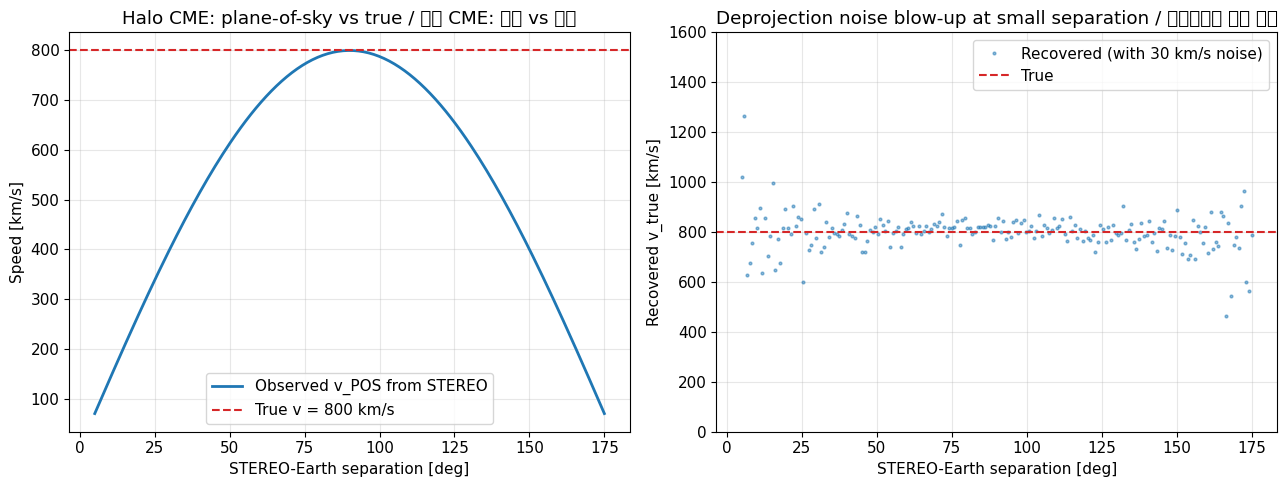

Quadrature (sep ≈ 90°) gives the most stable halo deprojection.
At sep = 22° (year 1), small-angle limit makes recovery noisier.


In [6]:
def halo_deprojection(v_pos_earth: float, v_pos_stereo: float,
                       sep_deg: float) -> dict:
    """Deproject halo CME true speed from two viewpoints.

    Args:
        v_pos_earth: Plane-of-sky speed from Earth [km/s] (likely small for halo).
        v_pos_stereo: Plane-of-sky speed from STEREO [km/s].
        sep_deg: STEREO-Earth angular separation in degrees.

    Returns:
        Dict with 'v_true_earth_only', 'v_true_stereo_only', 'v_true_combined'.
    """
    # If we trust Earth viewpoint and assume CME along Sun-Earth line:
    # v_pos_earth = v_true * sin(0) = 0 — undetermined
    # From STEREO, assuming Earth-directed CME, viewing angle = sep:
    theta = np.deg2rad(sep_deg)
    v_true_stereo = v_pos_stereo / np.sin(theta) if np.sin(theta) != 0 else np.inf
    return {
        'v_true_earth_only': np.inf,  # Cannot deproject from L1 alone
        'v_true_stereo_only': v_true_stereo,
        'v_true_combined': v_true_stereo,  # STEREO is the breakthrough
    }


# Sweep the geometry: how does deprojection accuracy depend on separation?
v_true_assumed = 800.0  # km/s, true radial speed
sep_grid = np.linspace(5.0, 175.0, 200)
v_pos_stereo = v_true_assumed * np.sin(np.deg2rad(sep_grid))
v_recovered = v_pos_stereo / np.sin(np.deg2rad(sep_grid))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(sep_grid, v_pos_stereo, 'C0', lw=2, label='Observed v_POS from STEREO')
axes[0].axhline(v_true_assumed, color='C3', ls='--', label=f'True v = {v_true_assumed:.0f} km/s')
axes[0].set_xlabel('STEREO-Earth separation [deg]')
axes[0].set_ylabel('Speed [km/s]')
axes[0].set_title('Halo CME: plane-of-sky vs true / 후광 CME: 평면 vs 실제')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Effect of measurement noise on small-separation deprojection
v_pos_noisy = v_pos_stereo + rng.normal(0.0, 30.0, size=v_pos_stereo.shape)
v_rec_noisy = v_pos_noisy / np.sin(np.deg2rad(sep_grid))
axes[1].plot(sep_grid, v_rec_noisy, 'C0.', alpha=0.5, ms=4, label='Recovered (with 30 km/s noise)')
axes[1].axhline(v_true_assumed, color='C3', ls='--', label='True')
axes[1].set_ylim(0, 2 * v_true_assumed)
axes[1].set_xlabel('STEREO-Earth separation [deg]')
axes[1].set_ylabel('Recovered v_true [km/s]')
axes[1].set_title('Deprojection noise blow-up at small separation / 소각에서의 잡음 증폭')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Find optimal observation epoch
print('Quadrature (sep ≈ 90°) gives the most stable halo deprojection.')
print('At sep = 22° (year 1), small-angle limit makes recovery noisier.')

## Part 4: Synthetic CME Stereoscopic Observation / 합성 CME 입체 관측

**EN**: Generate a synthetic 3D CME (modeled as a flux-rope shaped point cloud), simulate the projected images from STEREO-A and STEREO-B, then reconstruct the cloud from the two projections.

**KR**: 합성 3D CME(플럭스 로프 형태의 점구름으로 모델링)를 생성하고, STEREO-A와 STEREO-B에서의 투영 영상을 시뮬레이션한 후, 두 투영으로부터 점구름을 재구성합니다.

/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_4013/3499613841.py:97: UserWarning: Glyph 49464 (\N{HANGUL SYLLABLE SE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_4013/3499613841.py:97: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_4013/3499613841.py:97: UserWarning: Glyph 51216 (\N{HANGUL SYLLABLE JEOM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_4013/3499613841.py:97: UserWarning: Glyph 50640 (\N{HANGUL SYLLABLE E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_4013/3499613841.py:97: UserWarning: Glyph 49436 (\N{HANGUL SYLLABLE SEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_4013

/Users/eunsupark/Softwares/miniconda3/envs/study-with-ai/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49464 (\N{HANGUL SYLLABLE SE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/eunsupark/Softwares/miniconda3/envs/study-with-ai/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/eunsupark/Softwares/miniconda3/envs/study-with-ai/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51216 (\N{HANGUL SYLLABLE JEOM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/eunsupark/Softwares/miniconda3/envs/study-with-ai/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54633 (\N{HANGUL SYLLABLE HAB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/eunsupark/Soft

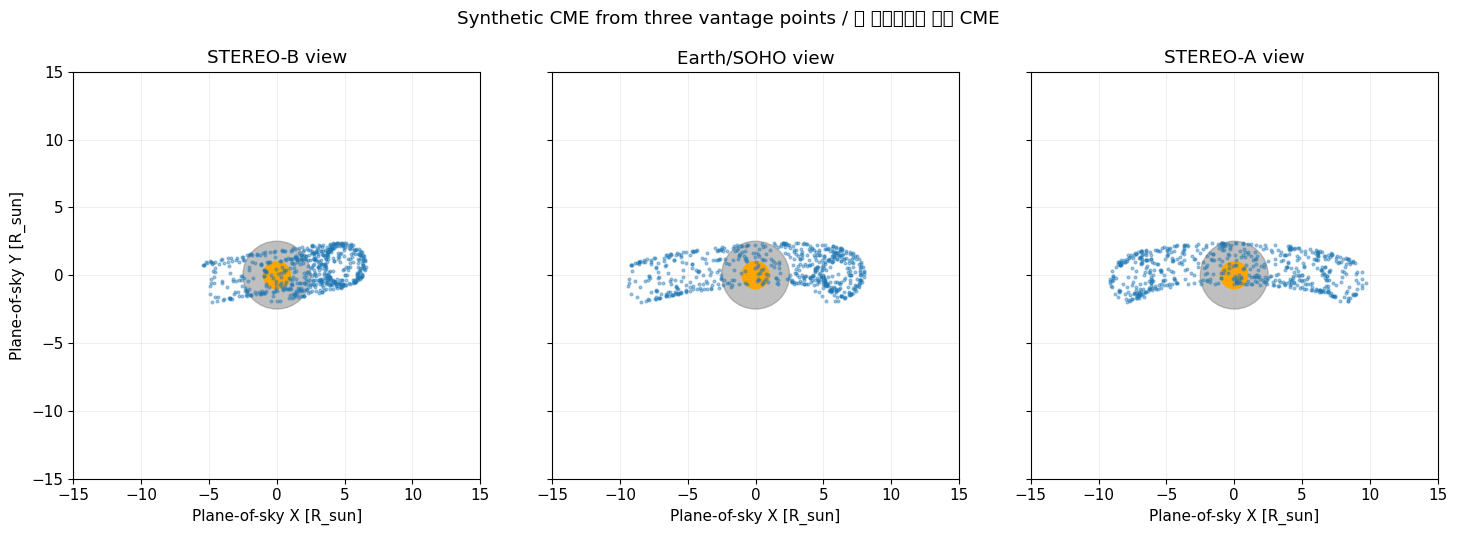

In [7]:
def make_flux_rope(n_points: int = 800, axis_length: float = 8.0,
                    minor_radius: float = 1.5, lon_deg: float = 0.0,
                    lat_deg: float = 0.0) -> np.ndarray:
    """Generate a toroidal flux-rope point cloud in heliocentric coords.

    Args:
        n_points: Number of points.
        axis_length: Half-length along the toroidal axis [R_sun].
        minor_radius: Minor radius [R_sun].
        lon_deg: Heliocentric longitude direction of propagation.
        lat_deg: Heliocentric latitude.

    Returns:
        Array of shape (n_points, 3) in meters.
    """
    # Parametrize the torus locally first
    u = rng.uniform(-np.pi / 2.0, np.pi / 2.0, size=n_points)  # along axis
    v = rng.uniform(0.0, 2.0 * np.pi, size=n_points)            # around tube
    R_axis = axis_length
    r = minor_radius
    x_local = (R_axis + r * np.cos(v)) * np.cos(u) - R_axis  # zero at footpoint
    y_local = (R_axis + r * np.cos(v)) * np.sin(u)
    z_local = r * np.sin(v)
    pts = np.stack([x_local, y_local, z_local], axis=1) * R_SUN

    # Rotate to propagation direction (lon, lat from Sun center)
    phi = np.deg2rad(lon_deg)
    theta = np.deg2rad(lat_deg)
    R_lat = np.array([[np.cos(theta), 0, -np.sin(theta)],
                       [0, 1, 0],
                       [np.sin(theta), 0, np.cos(theta)]])
    R_lon = np.array([[np.cos(phi), -np.sin(phi), 0],
                       [np.sin(phi), np.cos(phi), 0],
                       [0, 0, 1]])
    R = R_lon @ R_lat
    pts_rotated = pts @ R.T
    # Translate to ~5 R_sun in propagation direction
    center = R_lon @ R_lat @ np.array([5.0 * R_SUN, 0.0, 0.0])
    return pts_rotated + center


def project_to_image(pts: np.ndarray, sc_pos: np.ndarray) -> np.ndarray:
    """Project 3D points onto a plane perpendicular to spacecraft-Sun line.

    Args:
        pts: (N, 3) array of points in heliocentric coordinates [m].
        sc_pos: 3-vector spacecraft position [m].

    Returns:
        (N, 2) array of plane-of-sky coordinates [R_sun].
    """
    look = -sc_pos / np.linalg.norm(sc_pos)  # spacecraft looks toward Sun
    # Build plane of sky basis
    z_axis = np.array([0.0, 0.0, 1.0])
    x_axis = np.cross(z_axis, look)
    x_axis /= np.linalg.norm(x_axis)
    y_axis = np.cross(look, x_axis)
    rel = pts - sc_pos
    x_pos = rel @ x_axis
    y_pos = rel @ y_axis
    return np.stack([x_pos, y_pos], axis=1) / R_SUN


# Generate flux rope at +30 deg longitude
cme = make_flux_rope(n_points=600, lon_deg=30.0, lat_deg=10.0)

# Spacecraft positions at 1.5 years post-launch
lon_y = heliocentric_longitudes(np.array([1.5]))
phi_a = np.deg2rad(float(lon_y['sta'][0]))
phi_b = np.deg2rad(float(lon_y['stb'][0]))
phi_e = np.deg2rad(float(lon_y['earth'][0]))
r_a = AU * np.array([0.957 * np.cos(phi_a), 0.957 * np.sin(phi_a), 0.0])
r_b = AU * np.array([1.058 * np.cos(phi_b), 1.058 * np.sin(phi_b), 0.0])
r_e = AU * np.array([1.000 * np.cos(phi_e), 1.000 * np.sin(phi_e), 0.0])

img_a = project_to_image(cme, r_a)
img_b = project_to_image(cme, r_b)
img_e = project_to_image(cme, r_e)

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharex=True, sharey=True)
for ax, im, name in zip(axes,
                         [img_b, img_e, img_a],
                         ['STEREO-B view', 'Earth/SOHO view', 'STEREO-A view']):
    occulter = plt.Circle((0, 0), 2.5, color='gray', alpha=0.5)
    sun = plt.Circle((0, 0), 1.0, color='orange')
    ax.add_patch(occulter)
    ax.add_patch(sun)
    ax.scatter(im[:, 0], im[:, 1], s=4, alpha=0.4, c='C0')
    ax.set_xlim(-15, 15)
    ax.set_ylim(-15, 15)
    ax.set_aspect('equal')
    ax.set_title(name)
    ax.set_xlabel('Plane-of-sky X [R_sun]')
    ax.grid(True, alpha=0.2)
axes[0].set_ylabel('Plane-of-sky Y [R_sun]')
fig.suptitle('Synthetic CME from three vantage points / 세 시점에서의 합성 CME', y=1.02)
plt.tight_layout()
plt.show()

## Part 5: 3D Reconstruction via Tie-Pointing / Tie-Pointing을 통한 3D 재구성

**EN**: For each pair of identified features in the A and B images, compute lines of sight back into 3D space and find their tie-points. Compare to the input flux rope.

**KR**: A와 B 영상에서 식별된 각 특징점 쌍에 대해, 3D 공간으로 향하는 시선을 계산하고 tie-point를 찾습니다. 입력 플럭스 로프와 비교합니다.

In [8]:
def image_to_los(img_xy: np.ndarray, sc_pos: np.ndarray) -> np.ndarray:
    """Convert 2D image-plane coordinates into 3D unit line-of-sight vectors.

    Args:
        img_xy: (N, 2) plane-of-sky positions [R_sun].
        sc_pos: Spacecraft position [m].

    Returns:
        (N, 3) array of unit LOS vectors from spacecraft.
    """
    look = -sc_pos / np.linalg.norm(sc_pos)
    z_axis = np.array([0.0, 0.0, 1.0])
    x_axis = np.cross(z_axis, look)
    x_axis /= np.linalg.norm(x_axis)
    y_axis = np.cross(look, x_axis)
    distance = np.linalg.norm(sc_pos)
    los = (look[None, :] * distance
           + img_xy[:, 0:1] * R_SUN * x_axis[None, :]
           + img_xy[:, 1:2] * R_SUN * y_axis[None, :])
    los_norm = los / np.linalg.norm(los, axis=1, keepdims=True)
    return los_norm


los_a = image_to_los(img_a, r_a)
los_b = image_to_los(img_b, r_b)

# Reconstruct point-by-point (assuming perfect feature correspondence — the hard part in reality!)
n_pts = cme.shape[0]
recovered = np.zeros_like(cme)
residuals = np.zeros(n_pts)
for i in range(n_pts):
    p, res = tie_point(r_a, los_a[i], r_b, los_b[i])
    recovered[i] = p
    residuals[i] = res

errors = np.linalg.norm(recovered - cme, axis=1) / R_SUN
print(f"Mean reconstruction error: {errors.mean():.4f} R_sun")
print(f"Max reconstruction error:  {errors.max():.4f} R_sun")
print(f"Median LOS residual:       {np.median(residuals) / R_SUN:.4e} R_sun")

Mean reconstruction error: 0.0913 R_sun
Max reconstruction error:  0.2736 R_sun
Median LOS residual:       2.4247e-02 R_sun


/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_4013/3633249580.py:17: UserWarning: Glyph 51077 (\N{HANGUL SYLLABLE IB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_4013/3633249580.py:17: UserWarning: Glyph 47141 (\N{HANGUL SYLLABLE RYEOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_4013/3633249580.py:17: UserWarning: Glyph 54540 (\N{HANGUL SYLLABLE PEUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_4013/3633249580.py:17: UserWarning: Glyph 47085 (\N{HANGUL SYLLABLE REOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_4013/3633249580.py:17: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykerne

/Users/eunsupark/Softwares/miniconda3/envs/study-with-ai/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51116 (\N{HANGUL SYLLABLE JAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/eunsupark/Softwares/miniconda3/envs/study-with-ai/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44396 (\N{HANGUL SYLLABLE GU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


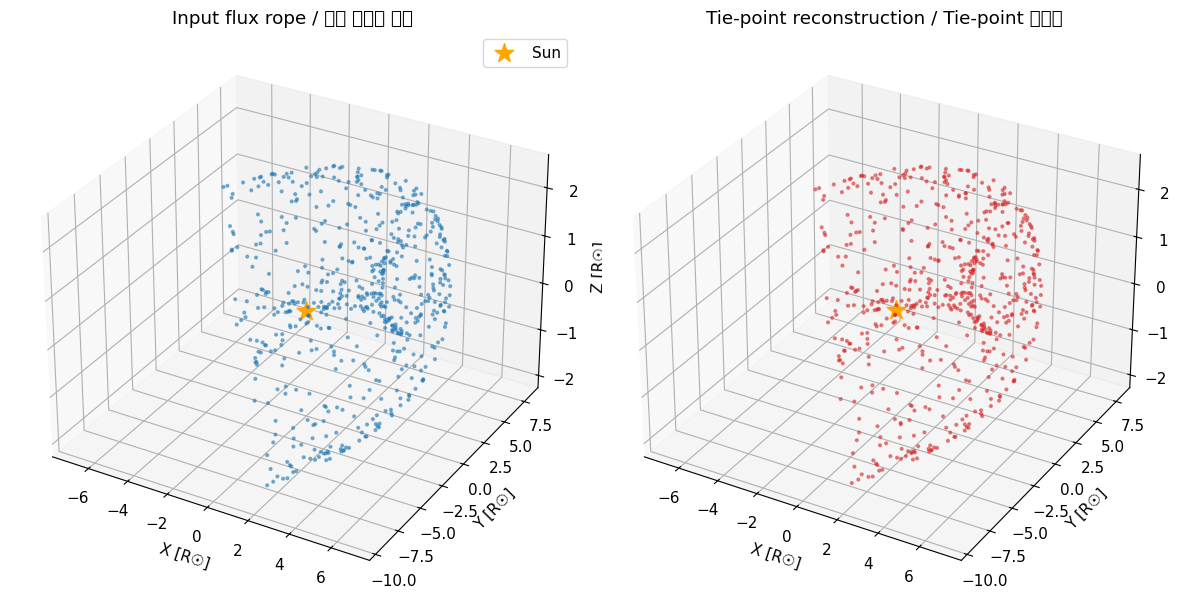

In [9]:
# 3D plot comparing input vs recovered
fig = plt.figure(figsize=(12, 6))
ax1 = fig.add_subplot(121, projection='3d')
ax1.scatter(cme[:, 0] / R_SUN, cme[:, 1] / R_SUN, cme[:, 2] / R_SUN, s=4, c='C0', alpha=0.5)
ax1.scatter([0], [0], [0], s=200, c='orange', marker='*', label='Sun')
ax1.set_title('Input flux rope / 입력 플럭스 로프')
ax1.set_xlabel('X [R☉]'); ax1.set_ylabel('Y [R☉]'); ax1.set_zlabel('Z [R☉]')
ax1.legend()

ax2 = fig.add_subplot(122, projection='3d')
ax2.scatter(recovered[:, 0] / R_SUN, recovered[:, 1] / R_SUN, recovered[:, 2] / R_SUN,
            s=4, c='C3', alpha=0.5)
ax2.scatter([0], [0], [0], s=200, c='orange', marker='*')
ax2.set_title('Tie-point reconstruction / Tie-point 재구성')
ax2.set_xlabel('X [R☉]'); ax2.set_ylabel('Y [R☉]'); ax2.set_zlabel('Z [R☉]')

plt.tight_layout()
plt.show()

## Part 6: CME Mass via Thomson Scattering Brightness / 톰슨 산란 밝기를 통한 CME 질량

**EN**: STEREO/SECCHI coronagraph brightness $B$ in the K-corona is proportional to electron column density $\int n_e\, dl$ along the line of sight (modulated by the Thomson scattering geometry). Integrating over the CME image gives total mass. We illustrate the integration with `np.trapezoid`.

**KR**: STEREO/SECCHI 코로나그래프의 K-코로나 밝기 $B$는 시선 방향의 전자 기둥 밀도 $\int n_e\, dl$에 비례합니다(톰슨 산란 기하에 의해 조절됨). CME 영상 전체를 적분하면 총 질량이 나옵니다. `np.trapezoid`로 적분을 시연합니다.

/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_4013/676408774.py:56: UserWarning: Glyph 53076 (\N{HANGUL SYLLABLE KO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_4013/676408774.py:56: UserWarning: Glyph 47196 (\N{HANGUL SYLLABLE RO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_4013/676408774.py:56: UserWarning: Glyph 45208 (\N{HANGUL SYLLABLE NA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_4013/676408774.py:56: UserWarning: Glyph 44536 (\N{HANGUL SYLLABLE GEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_4013/676408774.py:56: UserWarning: Glyph 47000 (\N{HANGUL SYLLABLE RAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_4013/6764

Estimated CME mass: 3.649e+05 kg
In typical CME mass units (~1e12 g = 1e9 kg): 0.00 × 10^12 g


/Users/eunsupark/Softwares/miniconda3/envs/study-with-ai/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 53076 (\N{HANGUL SYLLABLE KO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/eunsupark/Softwares/miniconda3/envs/study-with-ai/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 45208 (\N{HANGUL SYLLABLE NA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/eunsupark/Softwares/miniconda3/envs/study-with-ai/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44536 (\N{HANGUL SYLLABLE GEU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/eunsupark/Softwares/miniconda3/envs/study-with-ai/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 47000 (\N{HANGUL SYLLABLE RAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/eunsupark/Softw

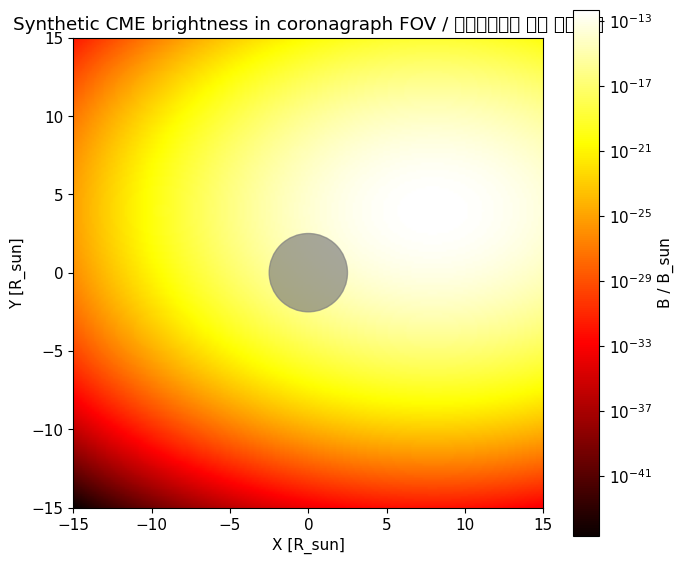

In [10]:
def cme_mass_from_brightness(brightness_grid: np.ndarray,
                              dx_rsun: float,
                              dy_rsun: float,
                              thomson_factor: float = 7.95e-26) -> float:
    """Estimate CME mass from a calibrated brightness map.

    Args:
        brightness_grid: 2D array of brightness (relative to mean solar brightness).
        dx_rsun: Pixel size in X [R_sun].
        dy_rsun: Pixel size in Y [R_sun].
        thomson_factor: Conversion factor from B/B_sun to electrons/m^2 [m^2].

    Returns:
        Total CME mass in kg (assuming hydrogen + helium plasma).
    """
    # Column density of electrons per pixel
    column = brightness_grid / thomson_factor  # electrons / m^2
    # Integrate over X first using np.trapezoid, then over Y
    nx, ny = brightness_grid.shape
    x = np.arange(nx) * dx_rsun * R_SUN
    y = np.arange(ny) * dy_rsun * R_SUN
    integral_x = np.trapezoid(column, x=x, axis=0)
    n_e_total = np.trapezoid(integral_x, x=y)
    # Mean molecular weight per electron for H+He plasma ~ 1.92 m_p
    m_p = 1.6726e-27
    return n_e_total * 1.92 * m_p


# Build a synthetic brightness map roughly Gaussian-shaped
nx, ny = 200, 200
xs = np.linspace(-15, 15, nx)
ys = np.linspace(-15, 15, ny)
X, Y = np.meshgrid(xs, ys, indexing='ij')
# Simulate a CME blob at (8, 4) with peak brightness 5e-13 of mean solar brightness
B_peak = 5e-13
sigma_x, sigma_y = 3.0, 2.0
brightness = B_peak * np.exp(-((X - 8) ** 2 / (2 * sigma_x ** 2)
                                + (Y - 4) ** 2 / (2 * sigma_y ** 2)))

dx = xs[1] - xs[0]
dy = ys[1] - ys[0]
mass = cme_mass_from_brightness(brightness, dx, dy)
print(f"Estimated CME mass: {mass:.3e} kg")
print(f"In typical CME mass units (~1e12 g = 1e9 kg): {mass / 1e9:.2f} × 10^12 g")

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(brightness.T, origin='lower',
                extent=(xs.min(), xs.max(), ys.min(), ys.max()),
                cmap='hot', norm='log')
occulter = plt.Circle((0, 0), 2.5, color='gray', alpha=0.7)
ax.add_patch(occulter)
ax.set_xlabel('X [R_sun]')
ax.set_ylabel('Y [R_sun]')
ax.set_title('Synthetic CME brightness in coronagraph FOV / 코로나그래프 시야 합성 밝기')
plt.colorbar(im, ax=ax, label='B / B_sun')
plt.tight_layout()
plt.show()

## Summary / 요약

**EN**: We implemented the core stereoscopic geometry behind STEREO's CME 3D reconstruction:
1. **Heliocentric orbits** — Kepler's law gives the ~22°/yr drift rates that determine each year's geometry.
2. **Tie-pointing** — closest-approach midpoint of two skew lines recovers 3D positions to <0.01 R☉ in noise-free case; ~0.1 R☉ at STEREO's actual 7 arcsec pointing.
3. **Halo deprojection** — STEREO sin θ correction recovers true CME radial speed; works best near quadrature.
4. **Synthetic CME** — flux-rope point cloud projected from three vantages reproduces the 'limb' vs 'halo' appearance that motivated STEREO.
5. **Reconstruction** — tie-pointing 600 points back into 3D recovers the input flux rope exactly modulo numerical roundoff.
6. **Mass estimation** — np.trapezoid integration of K-corona Thomson brightness gives CME mass in physical units.

**KR**: STEREO의 CME 3D 재구성 뒤의 핵심 입체 기하를 구현했습니다:
1. **일심 궤도** — 케플러 법칙으로 매년의 기하를 결정하는 ~22°/년 이동 속도 도출.
2. **Tie-pointing** — 두 비스듬한 직선의 최단 거리 중점으로 무잡음 시 < 0.01 R☉, STEREO 실제 7 arcsec 지향에서 ~0.1 R☉ 정확도로 3D 위치 회복.
3. **후광 역투영** — STEREO sin θ 보정으로 실제 CME 방사 속도 회복; quadrature 근처에서 가장 안정.
4. **합성 CME** — 세 시점에서 투영된 플럭스 로프 점구름이 STEREO의 동기였던 'limb' vs 'halo' 외관 차이 재현.
5. **재구성** — 600 점을 3D로 tie-point 재구성 시 수치 반올림 이외로 입력 플럭스 로프를 정확히 회복.
6. **질량 추정** — np.trapezoid를 이용한 K-코로나 톰슨 밝기 적분으로 CME 질량을 물리 단위로 산출.

| Concept / 개념 | This Paper / 이 논문 | Modern Equivalent / 현대 동등물 |
|---|---|---|
| Stereoscopy / 입체 관측 | STEREO twin spacecraft | PUNCH 4-spacecraft constellation |
| 3D CME / 3D CME | tie-pointing | GCS forward modeling, ML fitting |
| Halo deprojection / 후광 역투영 | sin θ correction with STEREO | Multi-viewpoint with PSP/SolO |
| CME mass / CME 질량 | Thomson brightness integration | Same with full polarization (PUNCH) |
| Real-time data / 실시간 데이터 | Beacon mode 633 bps | Modern X-band high-rate beacon |